# Manpower Disruption DIIM Analysis

DIIM analysis for the manpower disruption scenario using the 2022 Input-Output Table.

## 1. Load Libraries & Functions

In [1]:
# Set working directory to project root
setwd("..")

library(openxlsx)
library(ggplot2)
library(reshape2)
library(gridExtra)
library(dplyr)
library(tidyverse)
# Helper: source R code from a Jupyter notebook (.ipynb)
source_notebook <- function(nb_path) {
  nb <- jsonlite::fromJSON(nb_path, simplifyVector = FALSE)
  code_cells <- Filter(function(cell) cell$cell_type == "code", nb$cells)
  code_lines <- unlist(lapply(code_cells, function(cell) {
    paste(unlist(cell$source), collapse = "")
  }))
  all_code <- paste(code_lines, collapse = "\n")
  eval(parse(text = all_code), envir = globalenv())
}

source_notebook("functions.ipynb")

Warning message:
“package ‘openxlsx’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


COVID data loaded successfully
Number of sectors: 15 
A matrix dimensions: 15 15 
Total output (x) sum: 1335525 
DIIM simulation completed
Total economic loss: 27391.1 million


## 2. Load Manpower Disruption Data

In [2]:
data <- download_manpower_data()
A <- data$A
x <- data$x
c <- data$c
q0 <- data$q0
q0[q0 == 0] <- 1e-8
c_star <- data$c_star
A_star <- data$A_star
a_ii <- diag(A_star)
qT <- q0/100
k <- log(q0 / qT) / (751 * (1 - a_ii))

## 3. Main DIIM Simulation

In [3]:
DIIM_model <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751, days_in_year = 365)

## 4. Inoperability Evolution

pdf 
  2

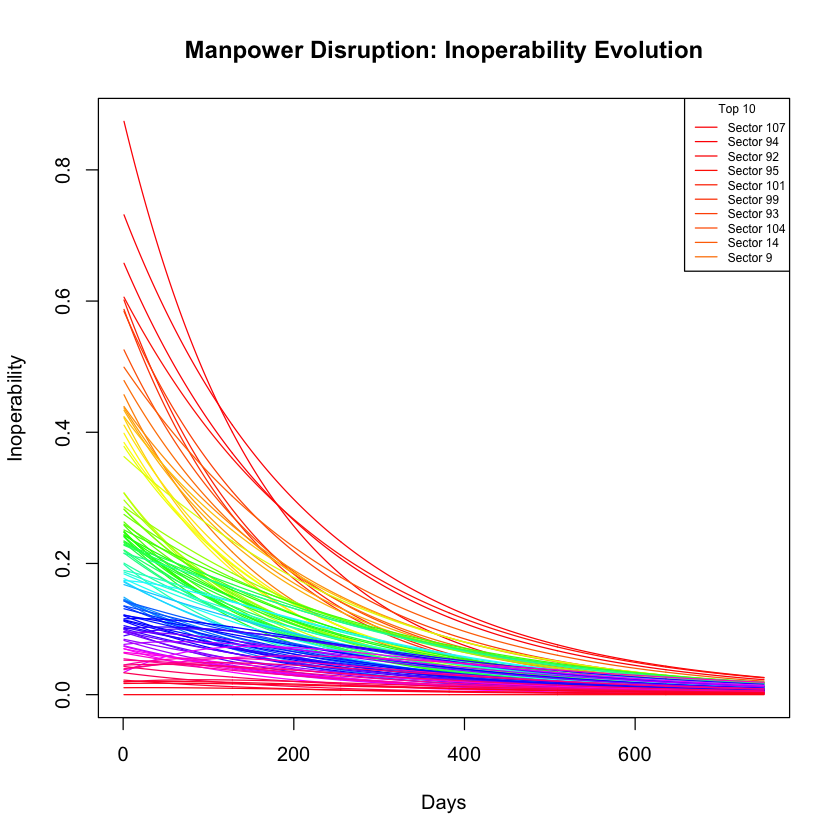

In [4]:
inoperability_evolution <- DIIM_model$inoperability_evolution
max_inoperability <- apply(inoperability_evolution, 1, max)
sorted_indices_inop <- order(max_inoperability, decreasing = TRUE)
sorted_inoperability <- inoperability_evolution[sorted_indices_inop, ]

num_sectors <- nrow(sorted_inoperability)
png("manpower-disruption/Inoperability_Evolution.png", units = "in", width = 10, height = 7, res = 300)
matplot(t(sorted_inoperability),
    type = "l", lty = 1, col = rainbow(num_sectors),
    xlab = "Days", ylab = "Inoperability",
    main = "Manpower Disruption: Inoperability Evolution")
legend("topright", legend = paste("Sector", sorted_indices_inop[1:10]), col = rainbow(num_sectors)[1:10], lty = 1, cex = 0.6, title = "Top 10")
dev.off()

# Display inline
matplot(t(sorted_inoperability),
    type = "l", lty = 1, col = rainbow(num_sectors),
    xlab = "Days", ylab = "Inoperability",
    main = "Manpower Disruption: Inoperability Evolution")
legend("topright", legend = paste("Sector", sorted_indices_inop[1:10]), col = rainbow(num_sectors)[1:10], lty = 1, cex = 0.6, title = "Top 10")

## 5. Economic Loss Evolution

pdf 
  2

[1] "Top 5 Sectors by Economic Loss:"
[1] 54 69 70 98 53


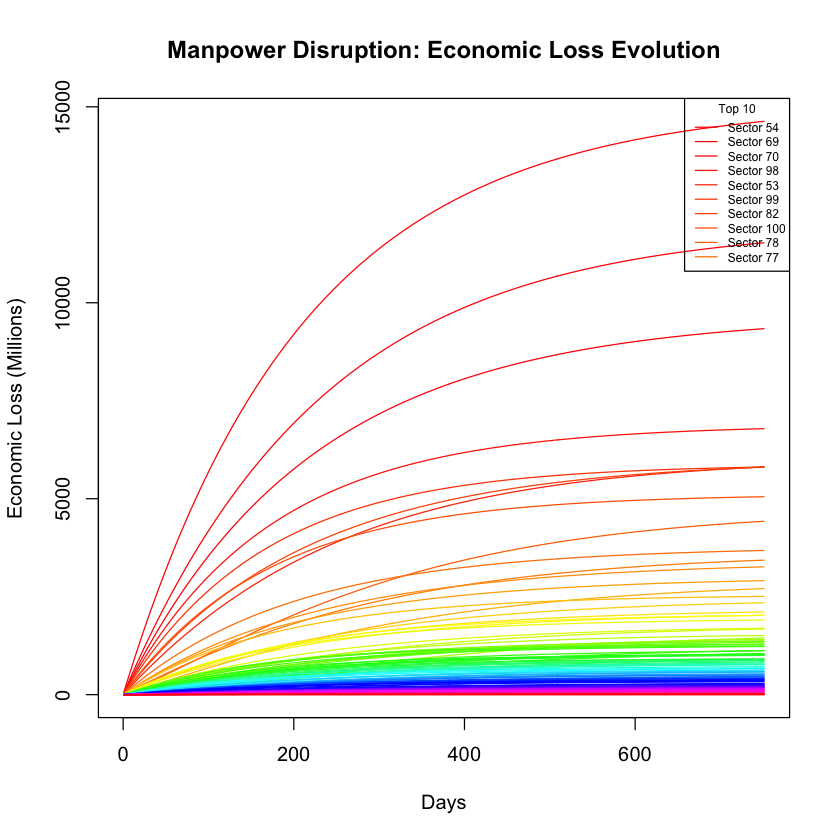

In [5]:
EL_evolution <- DIIM_model$EL_evolution
max_econ_loss <- apply(EL_evolution, 1, max)
sorted_indices_el <- order(max_econ_loss, decreasing = TRUE)
sorted_econ_loss <- EL_evolution[sorted_indices_el, ]

png("manpower-disruption/Economic_Loss_Evolution.png", units = "in", width = 10, height = 7, res = 300)
matplot(t(sorted_econ_loss),
    type = "l", lty = 1, col = rainbow(num_sectors),
    xlab = "Days", ylab = "Economic Loss (Millions)",
    main = "Manpower Disruption: Economic Loss Evolution")
legend("topright", legend = paste("Sector", sorted_indices_el[1:10]), col = rainbow(num_sectors)[1:10], lty = 1, cex = 0.6, title = "Top 10")
dev.off()

# Display inline
matplot(t(sorted_econ_loss),
    type = "l", lty = 1, col = rainbow(num_sectors),
    xlab = "Days", ylab = "Economic Loss (Millions)",
    main = "Manpower Disruption: Economic Loss Evolution")
legend("topright", legend = paste("Sector", sorted_indices_el[1:10]), col = rainbow(num_sectors)[1:10], lty = 1, cex = 0.6, title = "Top 10")

print("Top 5 Sectors by Economic Loss:")
print(sorted_indices_el[1:5])

## 6. Sensitivity Analysis: Lockdown Duration

In [6]:
output_40_days <- DIIM(q0, A_star, c_star, x, lockdown_duration = 40, total_duration = 751, days_in_year = 365)
loss_40 <- sum(output_40_days$total_economic_loss)

output_55_days <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751, days_in_year = 365)
loss_55 <- sum(output_55_days$total_economic_loss)

output_70_days <- DIIM(q0, A_star, c_star, x, lockdown_duration = 70, total_duration = 751, days_in_year = 365)
loss_70 <- sum(output_70_days$total_economic_loss)

print(paste("Total Loss (40 days):", loss_40))
print(paste("Total Loss (55 days):", loss_55))
print(paste("Total Loss (70 days):", loss_70))

[1] "Total Loss (40 days): 147407.45044415"
[1] "Total Loss (55 days): 147407.45044415"
[1] "Total Loss (70 days): 147407.45044415"


## 7. Risk Management Policy

In [7]:
policy_rm_1 <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751, risk_management = 0.95, days_in_year = 365)
print(paste("Total Loss (RM=0.95):", policy_rm_1$total_economic_loss))

[1] "Total Loss (RM=0.95): 154098.922585567"


## 8. Simulation Loop (DIIM Only)

In [8]:
lockdown_duration_vals <- c(10, 20, 30, 40)
total_duration_vals <- c(300, 400, 500, 600)

nsim <- length(lockdown_duration_vals) * length(total_duration_vals)
col_names <- c("lockdown_duration", "total_duration", "model_tot_econ_loss", "model_diim_tot_econ_loss")
sim_matrix <- matrix(data = NA, nrow = nsim, ncol = length(col_names))
colnames(sim_matrix) <- col_names
row_idx <- 1

print("--- Starting Simulation Loop ---")

for (td in total_duration_vals) {
    for (ld in lockdown_duration_vals) {
        model <- DIIM(q0, A_star, c_star, x, lockdown_duration = ld, total_duration = td, days_in_year = 365)
        base_loss <- model$total_economic_loss
        max_el <- apply(model$EL_evolution, 1, max)
        top_5 <- order(max_el, decreasing = TRUE)[1:5]
        model_diim <- DIIM(q0, A_star, c_star, x, lockdown_duration = ld, total_duration = td, key_sectors = top_5, days_in_year = 365)
        diim_loss <- model_diim$total_economic_loss
        sim_matrix[row_idx, ] <- c(ld, td, base_loss, diim_loss)
        row_idx <- row_idx + 1
    }
}

sim_df <- as.data.frame(sim_matrix)
print("Simulation Results:")
print(sim_df)

[1] "--- Starting Simulation Loop ---"
[1] "Simulation Results:"
   lockdown_duration total_duration model_tot_econ_loss
1                 10            300            58909.14
2                 20            300            58909.14
3                 30            300            58909.14
4                 40            300            58909.14
5                 10            400            78531.83
6                 20            400            78531.83
7                 30            400            78531.83
8                 40            400            78531.83
9                 10            500            98154.52
10                20            500            98154.52
11                30            500            98154.52
12                40            500            98154.52
13                10            600           117777.20
14                20            600           117777.20
15                30            600           117777.20
16                40            600    

## 9. Simulation Loop (ML vs DIIM)

In [9]:
lockdown_duration_vals = c(10, 20, 30, 40)
total_duration_vals = c(300, 400, 500, 600)

nsim = length(lockdown_duration_vals) * length(total_duration_vals)
col_names = c("lockdown_duration", "total_duration", "model_tot_econ_loss", "model_diim_tot_econ_loss", "model_ml_tot_econ_loss")
sim_matrix = matrix(data=NA, nrow=nsim, ncol=5)
colnames(sim_matrix) = col_names

row_idx = 1
for (l_duration in lockdown_duration_vals) {
  for (t_duration in total_duration_vals) {
    res = simulation_ml_vs_diim_manpower(q0, A_star, c_star, x, lockdown_duration=l_duration, total_duration=t_duration)
    res = matrix(unlist(res), ncol=5)
    sim_matrix[row_idx,] = res
    row_idx = row_idx + 1
  }
}

sim_df = as.data.frame(sim_matrix)
print(sim_df)

   lockdown_duration total_duration model_tot_econ_loss
1                 10            300            58748.18
2                 10            400            78317.26
3                 10            500            97886.34
4                 10            600           117455.41
5                 20            300            58748.18
6                 20            400            78317.26
7                 20            500            97886.34
8                 20            600           117455.41
9                 30            300            58748.18
10                30            400            78317.26
11                30            500            97886.34
12                30            600           117455.41
13                40            300            58748.18
14                40            400            78317.26
15                40            500            97886.34
16                40            600           117455.41
   model_diim_tot_econ_loss model_ml_tot_econ_lo